# Is the climate-graded SV purging real, or an artifact?

The per-variant arm (`temporal_s_consolidated.ipynb` §3, `sv_parallelism_climate.ipynb`) reports that
SV purging **intensifies at hot / arid gardens** — climate-slope beta sign-excess bio1 rho=+0.51
(p=0.0035), bio18 rho=-0.55 (p=0.0013), driven by insertions rather than by SV length.

## Read this first: the question has to be asked at the founder level

In global mode kMate's per-variant allele frequency is

$$\mathrm{AF}_v \;=\; \frac{\mathbf{h}^{\top} V_{pa}[:,v]}{\mathbf{h}^{\top} V_{called}[:,v]}$$

a deterministic projection of the per-sample founder mixture $\mathbf h$ through a *fixed* carrier
matrix. Two variants with the same carrier column have byte-identical trajectories — same `h`, same
projection, same noise. So a per-variant statistic carries information through exactly two channels:
**which founders carry the variant**, and **how those founders respond to climate**. There is no
per-SV degree of freedom for "selection on this SV" to occupy.

That is a property of the method, not a finding, and it means the per-variant climate-slope result and
the founder-level result below are **one result seen from two sides, not two pieces of evidence**.

So the claim the data *can* support is: **founders carrying more inserted sequence decline in hot /
arid gardens.** This notebook tests that claim's confounds.

## The measure: kb of inserted sequence

Throughout, founder SV content is **kb of sequence present in the founder and absent from
TAIR10/Col-0** — the raw base-pair total over that founder's carried SV insertions (>50 bp). Median
121 kb per founder.

This replaces the `ins_frac` (insertion count / total variant load) used in earlier drafts. §2.2 and
§2.4 show why: raw insertion **bp** is the strongest predictor on every test *and* the only insertion
measure free of a cactus/PanGenie panel artifact — insertion **counts** are badly panel-biased, and
normalising by variant load introduces a panel effect rather than removing one.

| # | worry | section |
|---|---|---|
| 1 | content tracks **cactus vs PanGenie panel membership** (+41% cactus EM bias) | §1 |
| 2 | insertion-rich founders come from **cold homes** and lose in hot gardens by local adaptation | §2.1 |
| 3 | "insertion content" is really **divergence from Col-0**, since the pangenome is Col-0-referenced | §2.3 |
| 4 | it is an artifact of **how the panel was built** — call quality, assembly-based vs genotyped | §2.4 |


## 0. Inputs

`gamma_f` = per-founder climate response = slope of the founder selection coefficient `S[site, f]` on
site climate across the 30 gardens. **Negative gamma_bio1 = that founder declines as the garden gets
hotter.** SV content and per-founder call rate are computed on a single common-variant filter
(MAC>=12, call rate>=0.9) in `_founder_sv_content.py`.

In [1]:

import os
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({'figure.dpi':110,'font.size':8,'axes.linewidth':0.6})

ROOT="/global/scratch/users/tbellg/kmate"
G=f"{ROOT}/analysis/grenenet_selection/r1_sv_negative_selection/results/sv_adaptive"
KEY="/global/scratch/users/tbellg/gea_grene-net/key_files"
os.makedirs(f"{G}/plots",exist_ok=True)

INS="#D55E00"; DEL="#0072B2"; BASE="0.8"; CAC="#009E73"; PGC="#CC79A7"
FIT="0.35"; ZERO="0.6"

def style(ax,axis="both"):
    # house scatter style (matches notebooks/plots/s_nofilter_climate_scatter.png)
    ax.set_axisbelow(True); ax.grid(color="0.88",lw=0.7,axis=axis)
    for sp in ax.spines.values(): sp.set_visible(False)

def pfmt(p):
    return f"{p:.1e}" if p<1e-4 else f"{p:.4f}"

def stat(ax,txt,loc=(0.03,0.03)):
    # plain grey stats line, bottom-left: no box, no bold, no interpretation
    ax.annotate(txt,xy=loc,xycoords="axes fraction",fontsize=9,color="0.3")

def rho_txt(r,p,pre=""):
    return f"{pre}\u03c1 = {r:+.2f}    p = {pfmt(p)}"

def fitline(ax,x,y,color=FIT):
    b,a0=np.polyfit(x,y,1); xs=np.array([x.min(),x.max()])
    ax.plot(xs,a0+b*xs,color=color,lw=1.5,ls="--",zorder=2)

def partial_spearman(x,y,Z):
    # Spearman of x,y after residualizing both RANKS on the ranks of Z.
    rx=stats.rankdata(x); ry=stats.rankdata(y)
    if Z is None:
        r=float(stats.spearmanr(x,y).correlation); dof=len(rx)-2
    else:
        RZ=np.column_stack([stats.rankdata(Z[:,j]) for j in range(Z.shape[1])])
        A=np.column_stack([np.ones(len(rx)),RZ])
        bx,*_=np.linalg.lstsq(A,rx,rcond=None); by,*_=np.linalg.lstsq(A,ry,rcond=None)
        ex=rx-A@bx; ey=ry-A@by; r=float(np.corrcoef(ex,ey)[0,1]); dof=len(rx)-2-Z.shape[1]
    t=r*np.sqrt(dof/max(1e-12,1-r**2))
    return r,float(2*stats.t.sf(abs(t),dof))

C=np.load(f"{G}/founder_climate_confound.npz",allow_pickle=True)
S=np.load(f"{G}/founder_sv_content.npz",allow_pickle=True)

founders=C["founders"].astype("U6"); keep=C["keep"].astype(bool); fid=founders[keep]
g1=C["gamma_bio1"][keep]; g18=C["gamma_bio18"][keep]
home1=C["home_bio1"][keep]; home18=C["home_bio18"][keep]
is_cac=C["is_cactus"][keep].astype(bool)
M={k:S[k][keep].astype(float) for k in S.files if k!="founders"}
for a,b in (("kb_ins","bp_ins"),("kb_del","bp_del"),("kb_sv","bp_sv")):
    M[a]=M[b]/1000.0
KB=M["kb_ins"]                       # <-- the headline measure
nsnp=M["n_snp"]; cr=M["call_rate_all"]
HOME=np.column_stack([home1,home18])
n=int(keep.sum())

print(f"founders: {n}  ({is_cac.sum()} cactus / {(~is_cac).sum()} PanGenie)")
print(f"HEADLINE  kb of inserted sequence: median {np.median(KB):,.0f} kb  "
      f"range {KB.min():,.0f}-{KB.max():,.0f} kb")
print(f"          kb deleted: median {np.median(M['kb_del']):,.0f} kb")
print(f"gamma_bio1 median {np.median(g1):+.5f}  sd {g1.std():.5f}")
print(f"per-founder call rate: median {np.median(cr):.4f}  range {cr.min():.4f}-{cr.max():.4f}")
print(f"divergence proxy n_snp median {nsnp.mean():,.0f}")


founders: 231  (80 cactus / 151 PanGenie)
HEADLINE  kb of inserted sequence: median 121 kb  range 44-202 kb
          kb deleted: median 569 kb
gamma_bio1 median -0.03267  sd 0.03663
per-founder call rate: median 0.9679  range 0.7583-0.9986
divergence proxy n_snp median 287,812


## 1. Panel asymmetry — cactus vs PanGenie

**The worry.** Only 80 of the 231 founders have long-read assemblies in the cactus pangenome; the
other 151 are PanGenie-genotyped from short reads. Insertions are exactly the class whose
*detectability* should differ, and `BACKGROUND.md` limitation 2 documents a **+41% cactus h-bias** in
the EM.

**This worry is partly justified — and it is what selects the measure.** Insertion *counts* really are
panel-biased; insertion *kb* is not. Both are shown.

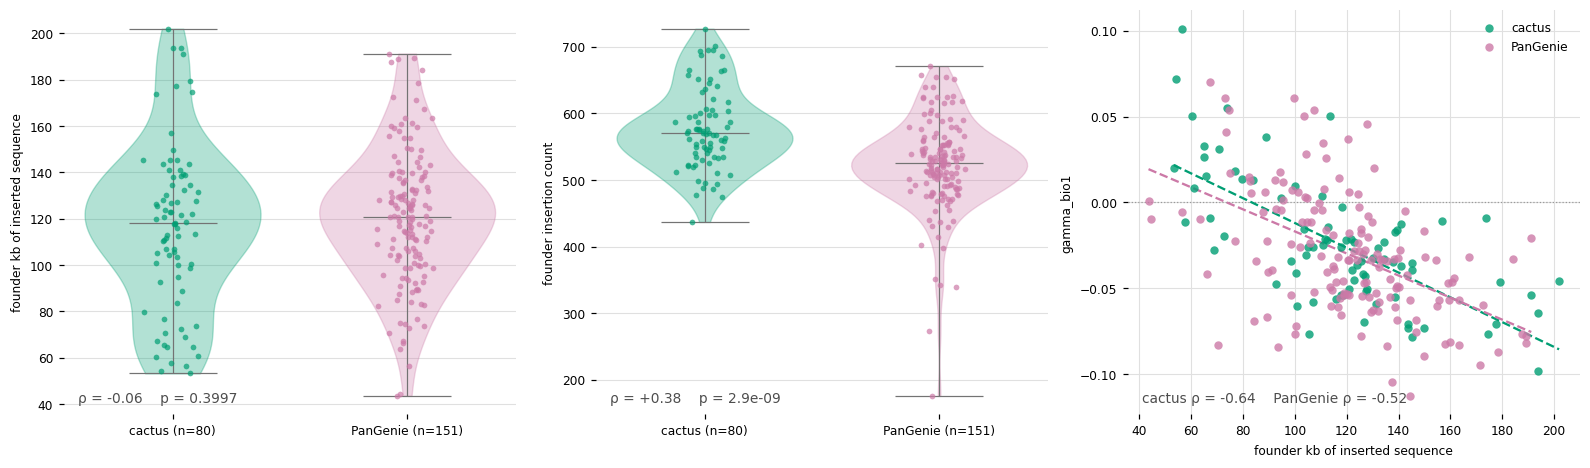

  kb inserted              vs panel half: rho=-0.056 p=0.3997
  insertion count          vs panel half: rho=+0.378 p=0.0000
  insertion count / load   vs panel half: rho=-0.096 p=0.1439
  insertion bp / load      vs panel half: rho=-0.224 p=0.0006

  gamma_bio1 vs panel half: rho=+0.068 p=0.302
  kb vs gamma within halves: cactus -0.644 (p=1.2e-10) | PanGenie -0.522 (p=6.0e-12)


In [2]:


fig,ax=plt.subplots(1,3,figsize=(14.5,4.3))
for a,(v,lab) in zip(ax[:2],[(KB,"kb of inserted sequence"),(M["n_ins"],"insertion count")]):
    style(a,axis="y")
    parts=[v[is_cac],v[~is_cac]]
    vp=a.violinplot(parts,positions=[0,1],showmedians=True,widths=0.75)
    for b,c in zip(vp['bodies'],[CAC,PGC]):
        b.set_facecolor(c); b.set_alpha(0.30); b.set_edgecolor(c); b.set_linewidth(0.9)
    for kk in ('cmedians','cbars','cmins','cmaxes'):
        if kk in vp: vp[kk].set_color("0.45"); vp[kk].set_linewidth(0.8)
    for i,(vv,c) in enumerate(zip(parts,[CAC,PGC])):
        a.scatter(np.full(vv.size,i)+np.random.default_rng(0).normal(0,0.055,vv.size),vv,
                  s=14,color=c,alpha=0.7,zorder=3,linewidths=0)
    a.set_xticks([0,1]); a.set_xticklabels([f"cactus (n={is_cac.sum()})",f"PanGenie (n={(~is_cac).sum()})"])
    a.set_ylabel(f"founder {lab}")
    r,p=stats.spearmanr(v,is_cac.astype(float))
    stat(a,rho_txt(r,p))

style(ax[2])
ax[2].axhline(0,color=ZERO,lw=0.8,ls=":")
for msk,c,lab in [(is_cac,CAC,"cactus"),(~is_cac,PGC,"PanGenie")]:
    ax[2].scatter(KB[msk],g1[msk],s=30,color=c,alpha=0.8,linewidths=0,label=lab,zorder=3)
    fitline(ax[2],KB[msk],g1[msk],color=c)
ax[2].set_xlabel("founder kb of inserted sequence")
ax[2].set_ylabel("gamma_bio1")
rc=stats.spearmanr(KB[is_cac],g1[is_cac]); rp=stats.spearmanr(KB[~is_cac],g1[~is_cac])
r_gc,p_gc=stats.spearmanr(g1,is_cac.astype(float))
stat(ax[2],f"cactus ρ = {rc.correlation:+.2f}    PanGenie ρ = {rp.correlation:+.2f}")
ax[2].legend(frameon=False,fontsize=8,loc="upper right")
fig.tight_layout(); fig.savefig(f"{G}/plots/confound_panel.png",dpi=130,bbox_inches="tight"); plt.show()

for k,lab in (("kb_ins","kb inserted"),("n_ins","insertion count"),
              ("n_ins_frac","insertion count / load"),("bp_ins_frac","insertion bp / load")):
    r,p=stats.spearmanr(M[k],is_cac.astype(float))
    print(f"  {lab:<24} vs panel half: rho={r:+.3f} p={p:.4f}")
print(f"\n  gamma_bio1 vs panel half: rho={r_gc:+.3f} p={p_gc:.3f}")
print(f"  kb vs gamma within halves: cactus {rc.correlation:+.3f} (p={rc.pvalue:.1e}) | "
      f"PanGenie {rp.correlation:+.3f} (p={rp.pvalue:.1e})")


**Verdict: the panel biases counts, not kb — and does not touch the result.**

Insertion **count** differs sharply between the halves (rho = +0.378, p < 0.001; cactus median 570 vs
PanGenie 525) — long-read assemblies resolve more insertion *records*, exactly the artifact this
section was looking for. Normalising by variant load does not fix it, it flips it (bp/load rho =
-0.224, p = 0.001).

Insertion **kb is clean**: rho = -0.056, **p = 0.40**, medians 118.2 vs 120.7 kb. It is the only
insertion measure with no panel signal.

And panel membership does not predict the climate response at all (gamma vs panel rho = +0.068,
p = 0.30), while the kb-vs-gamma slope holds **within each half separately** (cactus -0.644,
PanGenie -0.522). §2.4 pushes this further.

## 2. The confound that IS real — founder provenance

### 2.1 The triangle, and how far provenance goes

**The worry, and this time it lands.** Founders are locally adapted to where they came from. If
insertion-rich founders originate in cold / wet-summer places, they lose in hot / arid gardens for
reasons with nothing to do with their SVs.

**Model.** The three sides of the triangle — gamma vs origin climate, inserted kb vs origin climate,
gamma vs inserted kb — then the partial correlation of gamma with inserted kb under **escalating**
provenance control: origin bio1+bio18, then $k$ principal components of all 19 origin bioclim axes,
then all 19 raw. If the residual is really provenance in disguise, it should keep shrinking as the
control gets richer.

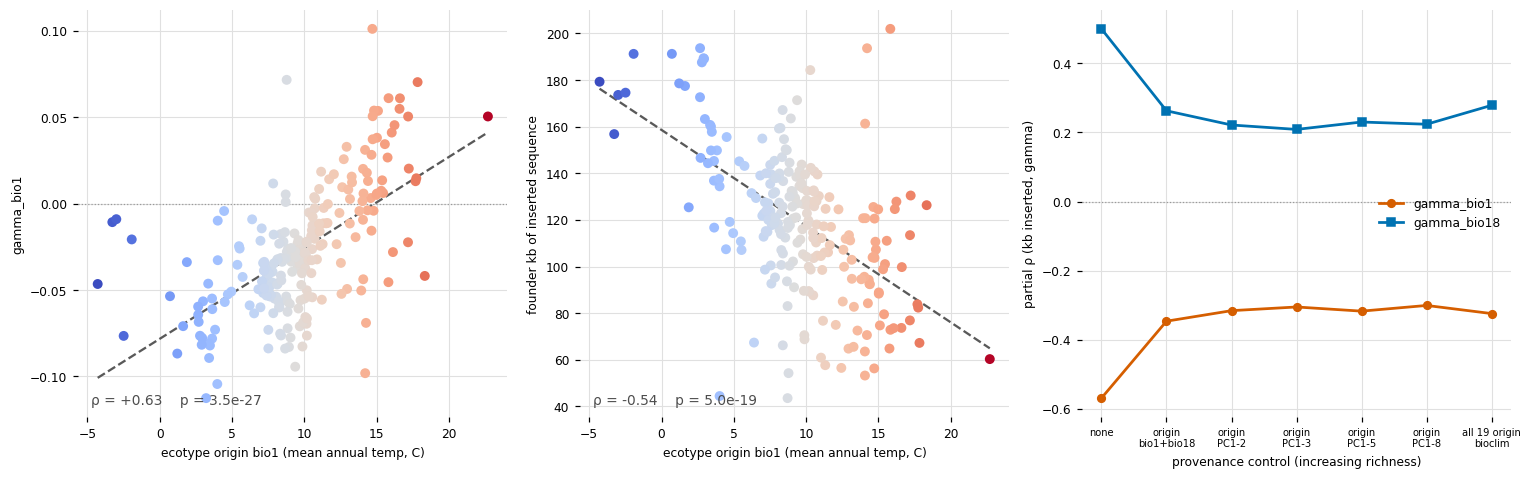

origin-climate PCA variance explained (first 5): [0.383 0.299 0.141 0.065 0.05 ]
gamma_bio1  vs origin bio1 : rho=+0.632
kb inserted vs origin bio1 : rho=-0.542
gamma_bio1  vs kb inserted : rho=-0.569

  partial | none                     bio1 -0.569 (p=3.0e-21)   bio18 +0.500 (p=5.0e-16)
  partial | origin bio1+bio18        bio1 -0.347 (p=7.3e-08)   bio18 +0.263 (p=5.7e-05)
  partial | origin PC1-2             bio1 -0.316 (p=1.1e-06)   bio18 +0.222 (p=7.3e-04)
  partial | origin PC1-3             bio1 -0.305 (p=2.6e-06)   bio18 +0.209 (p=1.5e-03)
  partial | origin PC1-5             bio1 -0.317 (p=1.1e-06)   bio18 +0.230 (p=4.8e-04)
  partial | origin PC1-8             bio1 -0.301 (p=4.8e-06)   bio18 +0.224 (p=7.6e-04)
  partial | all 19 origin bioclim    bio1 -0.324 (p=1.4e-06)   bio18 +0.279 (p=3.9e-05)


In [3]:


eco=pd.read_csv(f"{KEY}/1001g_regmap_grenet_ecotype_info_corrected_bioclim_2024May16.csv")
eco["ecotypeid"]=eco["ecotypeid"].astype(str); em=eco.set_index("ecotypeid")
BIOS=[f"bio{i}" for i in range(1,20)]
H=np.column_stack([[float(em.loc[f,b]) for f in fid] for b in BIOS])
Hz=(H-H.mean(0))/H.std(0)
U,sv_,Vt=np.linalg.svd(Hz,full_matrices=False); PCs=U*sv_
varexp=sv_**2/(sv_**2).sum()

specs=[("none",None),("origin\nbio1+bio18",Hz[:,[0,17]])]
for k in (2,3,5,8): specs.append((f"origin\nPC1-{k}",PCs[:,:k]))
specs.append(("all 19 origin\nbioclim",Hz))
rows=[(lab,)+partial_spearman(KB,g1,Z)+partial_spearman(KB,g18,Z) for lab,Z in specs]

fig,ax=plt.subplots(1,3,figsize=(14,4.4))
for a,(yv,yl) in zip(ax[:2],[(g1,"gamma_bio1"),(KB,"founder kb of inserted sequence")]):
    style(a)
    a.scatter(home1,yv,c=home1,cmap="coolwarm",s=42,zorder=3,edgecolor="none")
    fitline(a,home1,yv)
    r,p=stats.spearmanr(home1,yv)
    a.set_xlabel("ecotype origin bio1 (mean annual temp, C)"); a.set_ylabel(yl)
    stat(a,rho_txt(r,p))
ax[0].axhline(0,color=ZERO,lw=0.8,ls=":")

style(ax[2])
xs=np.arange(len(rows))
ax[2].axhline(0,color=ZERO,lw=0.8,ls=":")
ax[2].plot(xs,[r[1] for r in rows],"o-",color=INS,lw=1.8,ms=5,label="gamma_bio1")
ax[2].plot(xs,[r[3] for r in rows],"s-",color=DEL,lw=1.8,ms=5,label="gamma_bio18")
ax[2].set_xticks(xs); ax[2].set_xticklabels([r[0] for r in rows],fontsize=6.5)
ax[2].set_xlabel("provenance control (increasing richness)")
ax[2].set_ylabel("partial ρ (kb inserted, gamma)")
ax[2].legend(frameon=False,fontsize=8,loc="center right")
fig.tight_layout(); fig.savefig(f"{G}/plots/confound_provenance.png",dpi=130,bbox_inches="tight"); plt.show()

print(f"origin-climate PCA variance explained (first 5): {np.round(varexp[:5],3)}")
print(f"gamma_bio1  vs origin bio1 : rho={stats.spearmanr(home1,g1).correlation:+.3f}")
print(f"kb inserted vs origin bio1 : rho={stats.spearmanr(home1,KB).correlation:+.3f}")
print(f"gamma_bio1  vs kb inserted : rho={stats.spearmanr(KB,g1).correlation:+.3f}\n")
for lab,r1_,p1_,r18_,p18_ in rows:
    print(f"  partial | {lab.replace(chr(10),' '):24s} bio1 {r1_:+.3f} (p={p1_:.1e})   bio18 {r18_:+.3f} (p={p18_:.1e})")


**Verdict: a real partial confound that does not explain the effect away.**

Origin climate is the **strongest** founder-level predictor of the climate response (rho = +0.632 with
gamma_bio1) — textbook local adaptation, founders from warm homes do better in warm gardens. And
insertion-rich founders genuinely do come from colder homes (rho = -0.542 on kb). The two candidate
explanations are entangled.

But the attenuation **plateaus**: going from two origin axes to all nineteen barely moves the partial
correlation. A confound that was really doing the work should keep dissolving as the control gets
richer; this one hits a floor and sits there.

**Honest limit:** this shows the residual is not *origin climate as captured by these 19 bioclim
variables*. It does not show the residual is inserted sequence itself — another founder property that
travels with insertion content and that bioclim does not measure would look identical.

### 2.2 Why kb, and why insertions? SV content measured every way

SV content can be counted as a **number of SVs** or as **base pairs of genome affected** — a founder
with one 20 kb insertion and a founder with twenty 1 kb insertions have the same bp load and a 20x
different count. Both can be raw or normalised by total variant load, and separately for insertions
and deletions. All twelve are tested two ways:

- **Panel A — ecotype ORIGIN.** Do ecotypes from cold regions actually carry more inserted sequence?
  A property of the accessions, with no experimental data involved.
- **Panel B — selection IN the experiment.** `gamma_bio1`, how each founder fares as gardens warm,
  from its frequency trajectory across the 30 gardens.

Panel A is the premise of the proposed chain (*cold-origin ecotypes are insertion-rich → they are
purged in warm gardens → insertions look depleted in the heat*); panel B is its consequence. If the
chain is the whole story, holding origin fixed should collapse the link — that test is printed below.

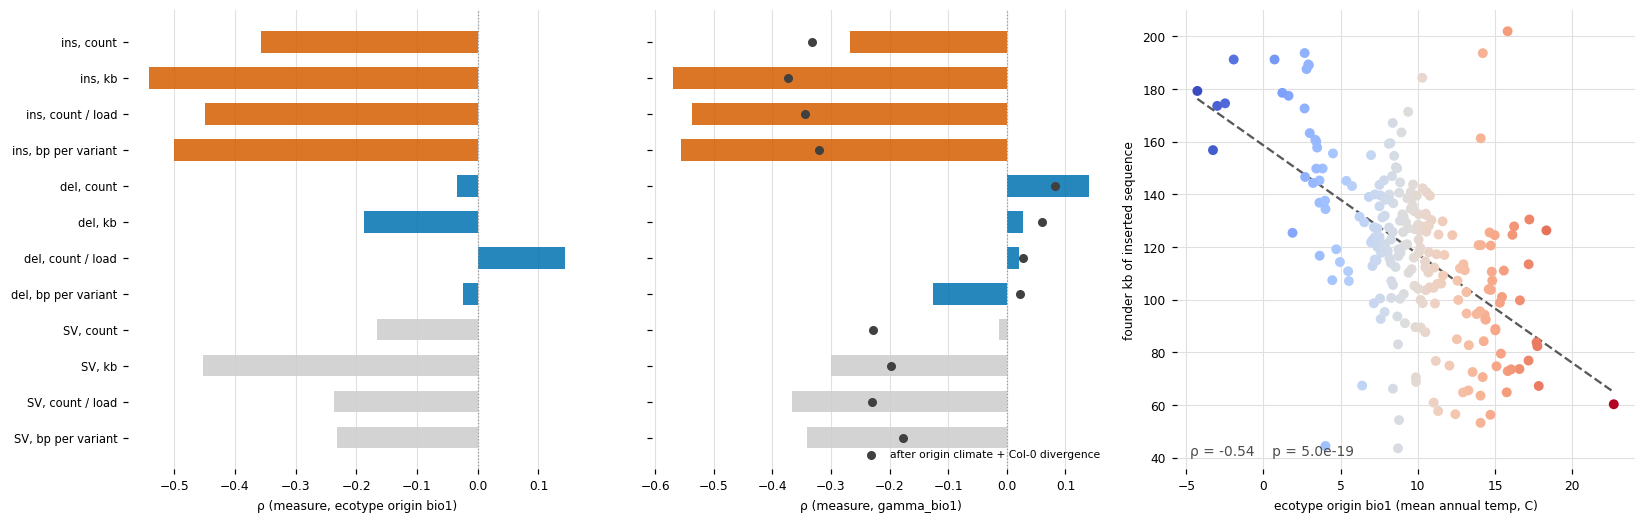

                lab   home   phome    gam    pgam   full   pfull
         ins, count -0.358 2.2e-08 -0.268 3.7e-05 -0.333 2.7e-07
            ins, kb -0.542 5.0e-19 -0.569 3.0e-21 -0.373 6.1e-09
  ins, count / load -0.450 6.8e-13 -0.537 1.2e-18 -0.344 9.8e-08
ins, bp per variant -0.500 5.3e-16 -0.556 3.8e-20 -0.320 8.1e-07
         del, count -0.034 6.1e-01 +0.141 3.2e-02 +0.081 2.2e-01
            del, kb -0.187 4.4e-03 +0.028 6.8e-01 +0.060 3.7e-01
  del, count / load +0.144 2.9e-02 +0.021 7.5e-01 +0.027 6.9e-01
del, bp per variant -0.025 7.1e-01 -0.125 5.7e-02 +0.022 7.4e-01
          SV, count -0.166 1.2e-02 -0.013 8.4e-01 -0.228 5.3e-04
             SV, kb -0.453 4.3e-13 -0.299 3.7e-06 -0.197 2.8e-03
   SV, count / load -0.237 2.8e-04 -0.366 9.4e-09 -0.231 4.4e-04
 SV, bp per variant -0.231 3.9e-04 -0.340 1.1e-07 -0.178 7.1e-03

--- the proposed chain, link by link (kb of inserted sequence) ---
  1. cold ORIGIN -> more inserted sequence      rho=-0.542 (p=5.0e-19)
  2. warm ORIGIN

In [4]:


MEAS=[("n_ins","ins, count",INS),("kb_ins","ins, kb",INS),
      ("n_ins_frac","ins, count / load",INS),("bp_ins_frac","ins, bp per variant",INS),
      ("n_del","del, count",DEL),("kb_del","del, kb",DEL),
      ("n_del_frac","del, count / load",DEL),("bp_del_frac","del, bp per variant",DEL),
      ("n_sv","SV, count",BASE),("kb_sv","SV, kb",BASE),
      ("n_sv_frac","SV, count / load",BASE),("bp_sv_frac","SV, bp per variant",BASE)]
tab=[]
for k,lab,c in MEAS:
    v=M[k]
    rh,ph=stats.spearmanr(v,home1); rg,pg=stats.spearmanr(v,g1)
    rf,pf=partial_spearman(v,g1,np.column_stack([home1,home18,nsnp]))
    tab.append(dict(key=k,lab=lab,col=c,home=rh,phome=ph,gam=rg,pgam=pg,full=rf,pfull=pf))
T=pd.DataFrame(tab)

fig,ax=plt.subplots(1,3,figsize=(15,4.8))
yy=np.arange(len(T))[::-1]
for a,vals,xl in ((ax[0],T.home,"ρ (measure, ecotype origin bio1)"),
                  (ax[1],T.gam,"ρ (measure, gamma_bio1)")):
    style(a,axis="x")
    a.axvline(0,color=ZERO,lw=0.8,ls=":")
    a.barh(yy,vals,color=T.col,alpha=0.85,height=0.6,linewidth=0)
    a.set_yticks(yy); a.set_xlabel(xl)
ax[0].set_yticklabels(T.lab,fontsize=7.5); ax[1].set_yticklabels([])
ax[1].scatter(T.full,yy,color="0.25",s=24,zorder=4,label="after origin climate + Col-0 divergence")
ax[1].legend(frameon=False,fontsize=7,loc="lower right")

style(ax[2])
ax[2].scatter(home1,KB,c=home1,cmap="coolwarm",s=42,zorder=3,edgecolor="none")
fitline(ax[2],home1,KB)
ax[2].set_xlabel("ecotype origin bio1 (mean annual temp, C)")
ax[2].set_ylabel("founder kb of inserted sequence")
rh2,ph2=stats.spearmanr(home1,KB)
stat(ax[2],rho_txt(rh2,ph2))
fig.tight_layout(); fig.savefig(f"{G}/plots/confound_sv_measures.png",dpi=130,bbox_inches="tight"); plt.show()

print(T[["lab","home","phome","gam","pgam","full","pfull"]].to_string(index=False,
      formatters={"home":"{:+.3f}".format,"gam":"{:+.3f}".format,"full":"{:+.3f}".format,
                  "phome":"{:.1e}".format,"pgam":"{:.1e}".format,"pfull":"{:.1e}".format}))

print("\n--- the proposed chain, link by link (kb of inserted sequence) ---")
rA=stats.spearmanr(home1,KB); rB=stats.spearmanr(home1,g1); rC=stats.spearmanr(KB,g1)
rC_h,pC_h=partial_spearman(KB,g1,home1[:,None])
print(f"  1. cold ORIGIN -> more inserted sequence      rho={rA.correlation:+.3f} (p={rA.pvalue:.1e})")
print(f"  2. warm ORIGIN -> survives heat better        rho={rB.correlation:+.3f} (p={rB.pvalue:.1e})")
print(f"  3. more inserted sequence -> declines in heat rho={rC.correlation:+.3f} (p={rC.pvalue:.1e})")
print(f"  link 3 with ORIGIN held fixed:                rho={rC_h:+.3f} (p={pC_h:.1e})")


**Yes — cold-origin ecotypes really do carry more inserted sequence**, and it is specific to
insertions: kb inserted vs origin bio1 rho = **-0.542**, while every deletion measure is flat against
origin climate. No experimental data enters panel A. Panel B has the same shape, which is what the
chain predicts.

**But the chain is not the whole story.** Holding origin climate fixed, the link between inserted kb
and selection weakens without collapsing. If cold-origin provenance were doing all the work, it would
go to ~0.

**Why kb is the headline.** Raw insertion bp is the strongest measure on every column here, and §1
already showed it is the only insertion measure free of a panel artifact. The `/load` normalisations
are also the hardest to read — "bp per variant carried" is base pairs divided by a *count*, which is
neither a length nor a proportion. Raw kb needs no explanation: sequence this ecotype has that Col-0
does not.

### 2.3 Is this just divergence from Col-0?

**The backbone, verified.** The minigraph-cactus graph was built over 82 long-read assemblies with
**TAIR10 (Col-0) as the reference backbone** — the panel VCF's contigs carry exact TAIR10 lengths
(Chr1 = 30,427,671 bp). But **Col-0 is not itself in the panel**: ecotype 6909 appears neither among
the 80 cactus assemblies nor among the 231 founders. Every founder's variant load is measured against
a genome that is not one of them, and **no founder sits at zero divergence**.

**The worry.** An "insertion" is by definition sequence a founder has and Col-0 lacks, so insertion
content is partly a statement about distance from Col-0. If divergence from Col-0 were
climate-structured, the whole result could be reference artifact.

**Model.** Take SNP ALT count (`n_snp`) as the divergence proxy. Ask whether divergence itself tracks
origin climate or gamma, and how entangled each SV measure is with it.

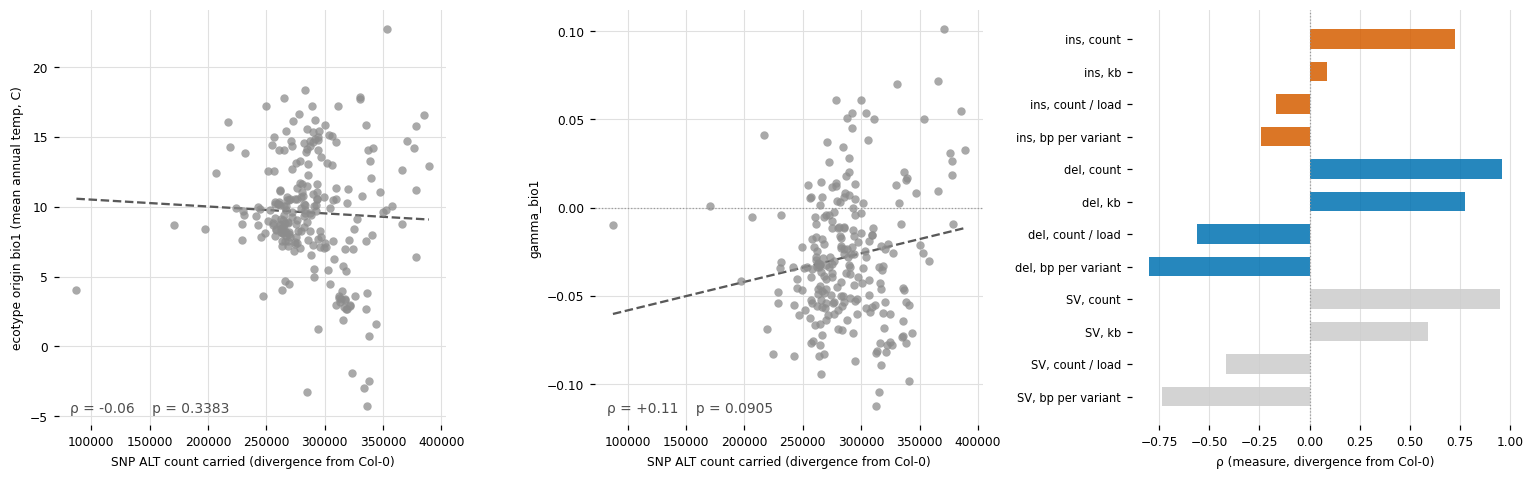

divergence vs origin bio1 : rho=-0.063 p=0.338
divergence vs gamma_bio1  : rho=+0.112 p=0.090

  ins, count               vs divergence: rho=+0.725
  ins, kb                  vs divergence: rho=+0.088
  ins, count / load        vs divergence: rho=-0.166
  ins, bp per variant      vs divergence: rho=-0.240
  del, count               vs divergence: rho=+0.958
  del, kb                  vs divergence: rho=+0.774
  del, count / load        vs divergence: rho=-0.560
  del, bp per variant      vs divergence: rho=-0.799
  SV, count                vs divergence: rho=+0.947
  SV, kb                   vs divergence: rho=+0.592
  SV, count / load         vs divergence: rho=-0.415
  SV, bp per variant       vs divergence: rho=-0.737

climatic distance to Col-0 vs genetic divergence: rho=+0.346
  kb inserted      vs climatic distance: raw +0.073 | ctrl origin +0.035 | ctrl DIVERGENCE +0.045 (p=0.50)
  deletion count   vs climatic distance: raw +0.312 | ctrl origin +0.311 | ctrl DIVERGENCE -0.071 (p

In [5]:


fig,ax=plt.subplots(1,3,figsize=(14,4.4))
for a,(yv,yl) in zip(ax[:2],[(home1,"ecotype origin bio1 (mean annual temp, C)"),(g1,"gamma_bio1")]):
    style(a)
    a.scatter(nsnp,yv,s=30,color="0.55",alpha=0.75,linewidths=0,zorder=3)
    fitline(a,nsnp,yv)
    r,p=stats.spearmanr(nsnp,yv)
    a.set_xlabel("SNP ALT count carried (divergence from Col-0)"); a.set_ylabel(yl)
    stat(a,rho_txt(r,p))
ax[1].axhline(0,color=ZERO,lw=0.8,ls=":")

ent=[(lab,stats.spearmanr(M[k],nsnp).correlation,c) for k,lab,c in MEAS]
yy=np.arange(len(ent))[::-1]
style(ax[2],axis="x")
ax[2].axvline(0,color=ZERO,lw=0.8,ls=":")
ax[2].barh(yy,[e[1] for e in ent],color=[e[2] for e in ent],alpha=0.85,height=0.6,linewidth=0)
ax[2].set_yticks(yy); ax[2].set_yticklabels([e[0] for e in ent],fontsize=7.5)
ax[2].set_xlabel("ρ (measure, divergence from Col-0)")
fig.tight_layout(); fig.savefig(f"{G}/plots/confound_col0_divergence.png",dpi=130,bbox_inches="tight"); plt.show()

rdh,pdh=stats.spearmanr(nsnp,home1); rdg,pdg=stats.spearmanr(nsnp,g1)
print(f"divergence vs origin bio1 : rho={rdh:+.3f} p={pdh:.3f}")
print(f"divergence vs gamma_bio1  : rho={rdg:+.3f} p={pdg:.3f}\n")
for lab,r,_ in ent: print(f"  {lab:<24} vs divergence: rho={r:+.3f}")

c0z=(np.array([float(em.loc["6909",b]) for b in BIOS])-H.mean(0))/H.std(0)
dist=np.linalg.norm(Hz-c0z,axis=1)
print(f"\nclimatic distance to Col-0 vs genetic divergence: rho={stats.spearmanr(dist,nsnp).correlation:+.3f}")
for k,lab in (("kb_ins","kb inserted"),("n_del","deletion count")):
    r,p=stats.spearmanr(M[k],dist)
    r1,_=partial_spearman(M[k],dist,home1[:,None]); r2,p2=partial_spearman(M[k],dist,nsnp[:,None])
    print(f"  {lab:<16} vs climatic distance: raw {r:+.3f} | ctrl origin {r1:+.3f} | ctrl DIVERGENCE {r2:+.3f} (p={p2:.2f})")


**Verdict: not a Col-0 artifact — but the choice of measure matters enormously.**

Divergence from Col-0 is **not climate-structured**: rho = -0.063 (p = 0.34) with origin bio1, +0.112
(p = 0.09) with gamma. It cannot be the source of a climate gradient it does not itself have.

The third panel is the part worth remembering. **SV counts are almost pure divergence statistics** —
deletion count vs SNP divergence **rho = +0.958**, i.e. very nearly the same variable; SV count +0.947.
That is expected: a more diverged founder carries more records of *every* class. **Inserted kb is the
exception at rho = +0.088 (p = 0.18)** — independent of divergence, and simultaneously the strongest
climate predictor in §2.2.

**Climatic distance to Col-0 gives a clean double dissociation.** Insertions are purely *directional*
(inserted kb vs distance is null once divergence is controlled); deletions show a distance
relationship that **vanishes entirely when genetic divergence is held fixed** (+0.312 → -0.071,
p = 0.29). The chain is: climatically peripheral founders are genetically more diverged (rho = +0.346),
and deletion count *is* divergence.

> **Caveat.** `n_snp` counts ALT alleles at *common, segregating* panel SNPs (MAC>=12), not raw
> sequence divergence — rare and private variants, which most distinguish relict lineages, are filtered
> out. And Col-0 is not a founder, so there is no zero-divergence anchor. Separately, the 1001G table
> places Col-0 in **Missouri, USA** (38.3, -92.3; bio1 13.1 C) — that is where the Laibach/Redei lineage
> was named, not collected, so no absolute "climatic distance to Col-0" number should be read as
> biological. A European-origin sensitivity anchor gives the same qualitative answer.

### 2.4 Could it be an artifact of how the panel was BUILT?

Every accession's SV content was *measured* by a pipeline. Two further routes by which that pipeline
could manufacture the pattern:

- **Call quality.** A founder whose genotypes are better resolved can carry more of everything.
  Per-founder call rate over the common panel is computable from `var_called` and is the direct
  covariate.
- **Assembly-based vs genotyped.** The two panel halves are measured by *completely different
  processes*: cactus founders get their insertions from their own long-read assembly; PanGenie
  founders have **no assembly at all** and are genotyped from short reads against a graph built from
  other accessions. If the origin-climate relationship holds **within the PanGenie half alone**, it
  cannot be an assembly-quality or assembly-technology effect — those founders were never assembled.

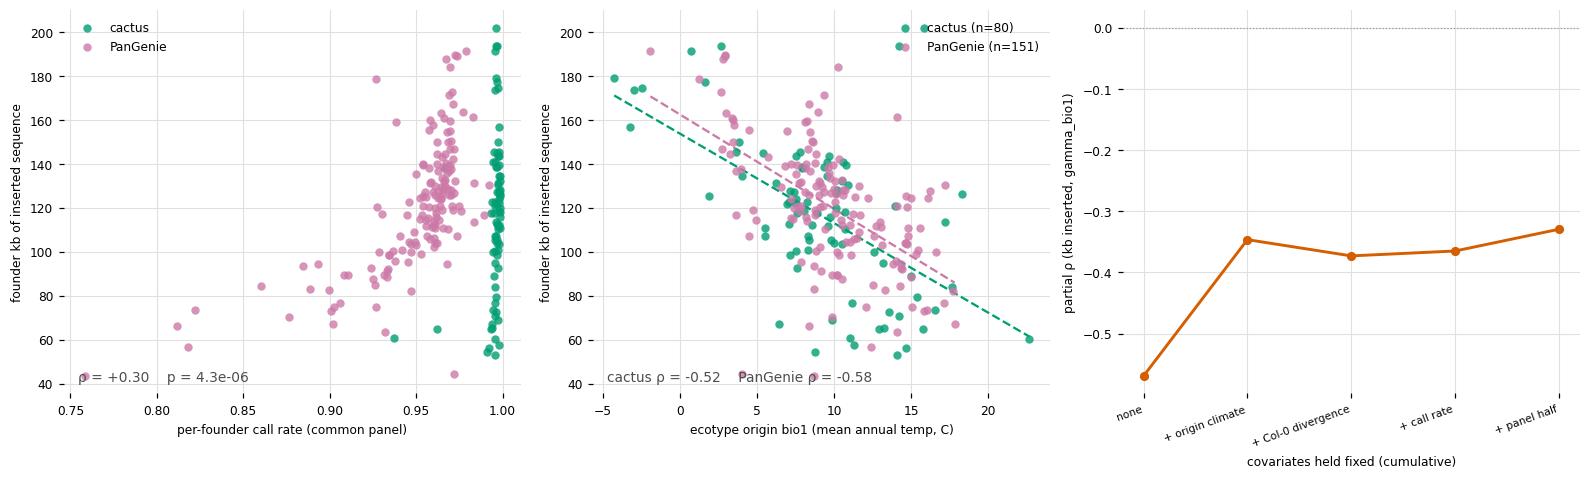

call rate: cactus median 0.9967 vs PanGenie 0.9608 (MWU p=3.0e-33)
call rate vs origin bio1: rho=-0.249
kb~origin with call rate fixed: -0.506 (was -0.542)

kb inserted vs ORIGIN bio1:  all -0.542 | cactus -0.523 (p=6.4e-07) | PanGenie -0.576 (p=1.0e-14)
kb inserted vs gamma_bio1 :  all -0.569 | cactus -0.644 | PanGenie -0.522
  partial(kb, gamma) | none                   = -0.569  (p=3.0e-21)
  partial(kb, gamma) | + origin climate       = -0.347  (p=7.3e-08)
  partial(kb, gamma) | + Col-0 divergence     = -0.373  (p=6.1e-09)
  partial(kb, gamma) | + call rate            = -0.365  (p=1.5e-08)
  partial(kb, gamma) | + panel half           = -0.330  (p=4.0e-07)


In [6]:


fig,ax=plt.subplots(1,3,figsize=(14.5,4.4))

style(ax[0])
for msk,c,lab in [(is_cac,CAC,"cactus"),(~is_cac,PGC,"PanGenie")]:
    ax[0].scatter(cr[msk],KB[msk],s=30,color=c,alpha=0.8,linewidths=0,label=lab,zorder=3)
ax[0].set_xlabel("per-founder call rate (common panel)")
ax[0].set_ylabel("founder kb of inserted sequence")
r_ck,p_ck=stats.spearmanr(cr,KB)
stat(ax[0],rho_txt(r_ck,p_ck))
ax[0].legend(frameon=False,fontsize=8,loc="upper left")

style(ax[1])
for msk,c,lab in [(is_cac,CAC,f"cactus (n={is_cac.sum()})"),
                  (~is_cac,PGC,f"PanGenie (n={(~is_cac).sum()})")]:
    ax[1].scatter(home1[msk],KB[msk],s=30,color=c,alpha=0.8,linewidths=0,label=lab,zorder=3)
    fitline(ax[1],home1[msk],KB[msk],color=c)
ax[1].set_xlabel("ecotype origin bio1 (mean annual temp, C)")
ax[1].set_ylabel("founder kb of inserted sequence")
rcc=stats.spearmanr(KB[is_cac],home1[is_cac]); rpp=stats.spearmanr(KB[~is_cac],home1[~is_cac])
stat(ax[1],f"cactus ρ = {rcc.correlation:+.2f}    PanGenie ρ = {rpp.correlation:+.2f}")
ax[1].legend(frameon=False,fontsize=8,loc="upper right")

ctrls=[("none",None),("+ origin climate",HOME),("+ Col-0 divergence",np.column_stack([HOME,nsnp])),
       ("+ call rate",np.column_stack([HOME,nsnp,cr])),
       ("+ panel half",np.column_stack([HOME,nsnp,cr,is_cac.astype(float)]))]
vals=[partial_spearman(KB,g1,Z) for _,Z in ctrls]
style(ax[2])
xs=np.arange(len(ctrls))
ax[2].axhline(0,color=ZERO,lw=0.8,ls=":")
ax[2].plot(xs,[v[0] for v in vals],"o-",color=INS,lw=1.9,ms=5)
ax[2].set_xticks(xs); ax[2].set_xticklabels([c[0] for c in ctrls],fontsize=7,rotation=20,ha="right")
ax[2].set_xlabel("covariates held fixed (cumulative)")
ax[2].set_ylabel("partial ρ (kb inserted, gamma_bio1)")
fig.tight_layout(); fig.savefig(f"{G}/plots/confound_technical.png",dpi=130,bbox_inches="tight"); plt.show()

print(f"call rate: cactus median {np.median(cr[is_cac]):.4f} vs PanGenie {np.median(cr[~is_cac]):.4f} "
      f"(MWU p={stats.mannwhitneyu(cr[is_cac],cr[~is_cac]).pvalue:.1e})")
print(f"call rate vs origin bio1: rho={stats.spearmanr(cr,home1).correlation:+.3f}")
print(f"kb~origin with call rate fixed: {partial_spearman(KB,home1,cr[:,None])[0]:+.3f} "
      f"(was {stats.spearmanr(KB,home1).correlation:+.3f})")
print(f"\nkb inserted vs ORIGIN bio1:  all {stats.spearmanr(KB,home1).correlation:+.3f} | "
      f"cactus {rcc.correlation:+.3f} (p={rcc.pvalue:.1e}) | PanGenie {rpp.correlation:+.3f} (p={rpp.pvalue:.1e})")
print(f"kb inserted vs gamma_bio1 :  all {stats.spearmanr(KB,g1).correlation:+.3f} | "
      f"cactus {stats.spearmanr(KB[is_cac],g1[is_cac]).correlation:+.3f} | "
      f"PanGenie {stats.spearmanr(KB[~is_cac],g1[~is_cac]).correlation:+.3f}")
for (lab,_),(r,p) in zip(ctrls,vals):
    print(f"  partial(kb, gamma) | {lab:<22} = {r:+.3f}  (p={p:.1e})")


**Verdict: not a construction artifact.**

**Call quality is a genuine candidate that does not deliver.** Call rate differs sharply between the
halves (cactus 0.9967 vs PanGenie 0.9608, p = 3e-33) and does track origin climate (rho = -0.249), so
it had to be checked. But holding it fixed barely moves the kb result (-0.542 → -0.506). It does dent
the *count* version (-0.358 → -0.275) — again isolating the problem to counts, not kb.

**The decisive test is the middle panel.** The origin-climate relationship holds in both halves, and is
*stronger* in the half with no assemblies at all (cactus -0.523, PanGenie **-0.576**). An
assembly-quality or long-read-technology effect cannot produce a signal that reproduces at full
strength in 151 founders who were never assembled. The same holds for the selection response (cactus
-0.644, PanGenie -0.522).

With **every** technical covariate held at once — origin climate, Col-0 divergence, call rate, panel
half — the association survives.

> **Open technical check, not covered here.** Sequencing *technology* (HiFi / CLR / ONT), assembly
> contiguity (N50) and assembly length are **not in this repo** — `data/request_assemblies_for_Moi.csv`
> carries only Assembly_ID / Accession_ID / version flags. Testing those needs the assembly metadata
> table from the source pangenome release. The PanGenie-half result above makes it unlikely to matter,
> but it has not been tested directly.

### 2.4b Genome content and graph representation

Three sharper instruments than the `n_snp` divergence proxy used in §2.3, which is MAC>=12-filtered
and so misses exactly the rare/private variation that marks divergent lineages:

- **Unfiltered divergence** (`n_snp_all`, ALT over every segregating record: median 524k vs 284k for
  the common-only version).
- **Graph representation** — per founder, kinship to the 80 assembly founders (self-excluded). The
  graph was built from 82 assemblies, so a founder far from all of them has insertions the graph
  cannot contain. This is what the construction worry is actually about, and `n_snp` cannot measure it.
- **Assembly size** — total chromosome-level length from the `.fai` indexes, for the 80 founders that
  have an assembly. The most direct genome-content control available: do cold-origin accessions simply
  have bigger genomes?

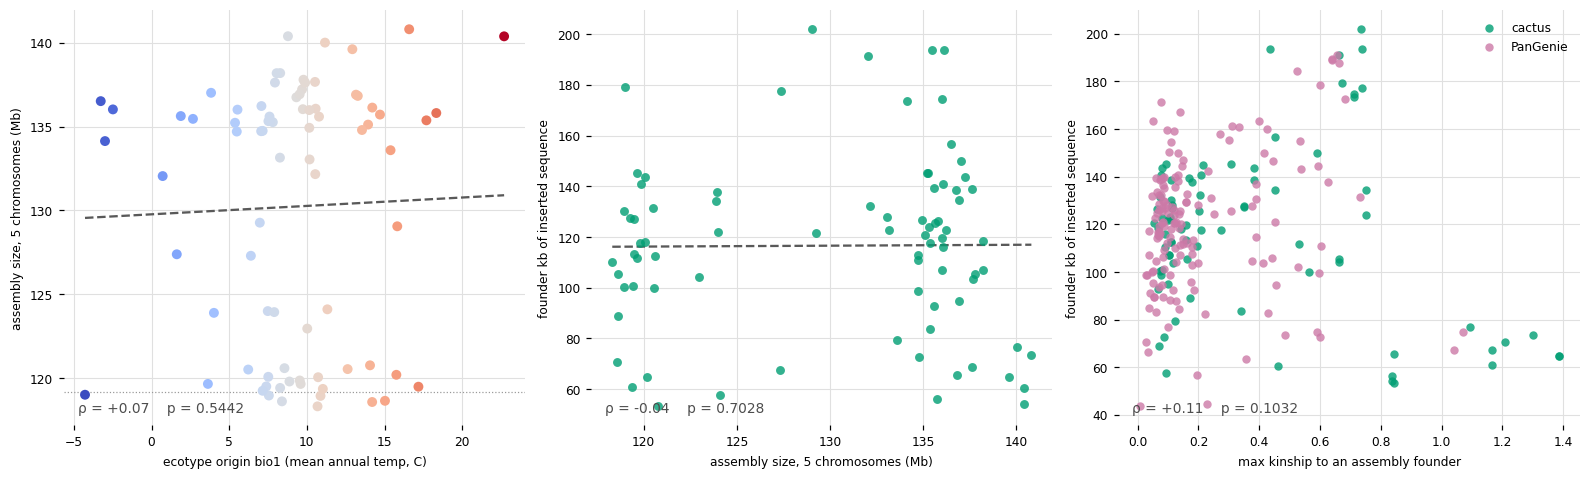

assemblies matched: 80 of 80 cactus founders
assembly size (Mb): median 134.73  range 118.31-140.81   (TAIR10 = 119.15)
  assembly size vs origin bio1    rho=+0.069 p=0.544
  assembly size vs kb inserted    rho=-0.043 p=0.703
  assembly size vs gamma_bio1     rho=+0.054 p=0.636

unfiltered divergence n_snp_all vs origin bio1: rho=-0.073
max kinship to assembly vs origin bio1: rho=-0.009
  kb~gamma | assembly size (cactus only)  = -0.643 (p=1.6e-10)
  kb~gamma | graph representation         = -0.629 (p=1.3e-26)
  kb~gamma | unfiltered divergence        = -0.582 (p=2.8e-22)


In [7]:

GRp=np.load(f"{G}/founder_graph_representation.npz",allow_pickle=True)
max_kin=GRp["max_kin"]; asm_mb=GRp["asm_mb"]; have=np.isfinite(asm_mb)

fig,ax=plt.subplots(1,3,figsize=(14.5,4.4))
style(ax[0])
ax[0].scatter(home1[have],asm_mb[have],c=home1[have],cmap="coolwarm",s=42,zorder=3,edgecolor="none")
fitline(ax[0],home1[have],asm_mb[have])
ax[0].axhline(119.15,color=ZERO,lw=0.8,ls=":")
ax[0].set_xlabel("ecotype origin bio1 (mean annual temp, C)")
ax[0].set_ylabel("assembly size, 5 chromosomes (Mb)")
r,p=stats.spearmanr(home1[have],asm_mb[have]); stat(ax[0],rho_txt(r,p))

style(ax[1])
ax[1].scatter(asm_mb[have],KB[have],s=34,color=CAC,alpha=0.8,linewidths=0,zorder=3)
fitline(ax[1],asm_mb[have],KB[have])
ax[1].set_xlabel("assembly size, 5 chromosomes (Mb)")
ax[1].set_ylabel("founder kb of inserted sequence")
r2,p2=stats.spearmanr(asm_mb[have],KB[have]); stat(ax[1],rho_txt(r2,p2))

style(ax[2])
for msk,c,lab in [(is_cac,CAC,"cactus"),(~is_cac,PGC,"PanGenie")]:
    ax[2].scatter(max_kin[msk],KB[msk],s=30,color=c,alpha=0.8,linewidths=0,label=lab,zorder=3)
ax[2].set_xlabel("max kinship to an assembly founder")
ax[2].set_ylabel("founder kb of inserted sequence")
r3,p3=stats.spearmanr(max_kin,KB); stat(ax[2],rho_txt(r3,p3))
ax[2].legend(frameon=False,fontsize=8,loc="upper right")
fig.tight_layout(); fig.savefig(f"{G}/plots/confound_genome_content.png",dpi=130,bbox_inches="tight"); plt.show()

print(f"assemblies matched: {int(have.sum())} of {int(is_cac.sum())} cactus founders")
print(f"assembly size (Mb): median {np.nanmedian(asm_mb[have]):.2f}  "
      f"range {np.nanmin(asm_mb[have]):.2f}-{np.nanmax(asm_mb[have]):.2f}   (TAIR10 = 119.15)")
for nm,v in (("origin bio1",home1),("kb inserted",KB),("gamma_bio1",g1)):
    rr,pp=stats.spearmanr(asm_mb[have],v[have])
    print(f"  assembly size vs {nm:<14} rho={rr:+.3f} p={pp:.3f}")
print(f"\nunfiltered divergence n_snp_all vs origin bio1: "
      f"rho={stats.spearmanr(M['n_snp_all'],home1).correlation:+.3f}")
print(f"max kinship to assembly vs origin bio1: rho={stats.spearmanr(max_kin,home1).correlation:+.3f}")
for lab,Z in (("assembly size (cactus only)",None),("graph representation",np.column_stack([max_kin,GRp['mean_kin']])),
              ("unfiltered divergence",M["n_snp_all"][:,None])):
    if Z is None:
        rr,pp=partial_spearman(KB[have],g1[have],asm_mb[have][:,None])
    else:
        rr,pp=partial_spearman(KB,g1,Z)
    print(f"  kb~gamma | {lab:<28} = {rr:+.3f} (p={pp:.1e})")


**Verdict: not a construction artifact, on any of the three.**

**Unfiltered divergence behaves exactly like the filtered version** — vs origin bio1 rho = -0.073
(p = 0.27), vs kb inserted +0.068. The weakness of the `n_snp` proxy turned out not to matter; the
better instrument gives the same answer, and holding it fixed leaves kb-vs-gamma at -0.582.

**Graph representation does not explain it.** Kinship to the assembly set is unrelated to origin
climate (max-kinship rho = -0.009, p = 0.89), and controlling for it makes the relationship
*stronger*, not weaker (kb~origin -0.542 -> -0.567; kb~gamma -0.569 -> -0.629). Within the PanGenie
half alone — the founders whose insertions can only come from what other accessions contributed —
kb~origin goes from -0.576 to **-0.633** once graph representation and unfiltered divergence are held
fixed.

**Assembly size is flat against everything.** All 80 cactus founders matched an assembly (median
134.7 Mb, range 118.3-140.8 Mb; TAIR10 is 119.2 Mb, so most assemblies are substantially larger).
Assembly size vs origin bio1 **rho = +0.069, p = 0.54** — cold-origin accessions do **not** have
bigger genomes. Assembly size vs inserted kb **rho = -0.043, p = 0.70** — inserted sequence is not
genome size. Holding it fixed changes nothing (kb~origin -0.523 -> -0.522; kb~gamma -0.644 -> -0.643).

That last result is worth pausing on: the most direct genome-content control available is completely
uninformative about insertion content. Consistent with the SV set being MAC>=12 *shared polymorphism*
rather than total sequence — assembly size is dominated by repeat and centromeric content that never
enters the graph as a callable insertion.

**A partial answer on sequencing technology.** Assembly size is visibly **bimodal** in the left panel —
30 assemblies at ~119.8 Mb and 50 at ~135.9 Mb — which almost certainly marks two different assembly
pipelines or platforms. That makes it a crude proxy for the technology covariate this notebook
otherwise cannot test. The two groups do **not** differ in ecotype origin climate (MWU p = 0.84),
inserted kb (p = 0.37) or gamma (p = 0.89), and the relationship holds **within each group separately**
(small: kb~origin rho = -0.681, p < 0.001; large: -0.435, p = 0.002). Not a substitute for the real
platform metadata, but it is the strongest technology-adjacent test available here and it comes back
negative.

### 2.4c Sequencing technology and assembly contiguity

Earlier passes flagged this as the one technical check that could not be run, because the metadata is
not in the kMate repo. It **is** in the assembly release
(`long_read_seq_ara/ASSEMBLIES_Best_version_of_dataset.csv`), carrying per assembly:
`Primary_Sequencing_Technology` (CLR / HiFi / ONT / ONT_R10.4 / ONT_HiFi), `Assembler`,
`N50_contigs`, `Gaps_Scaffolds`.

This matters because the platforms differ substantially in how well they resolve insertions relative to
a reference — HiFi is accurate through repeats, CLR is error-prone, ONT is long but noisier. If the
accessions sequenced on the better platform happened to come from colder places, the whole result would
be a platform artifact. 80 of the 80 cactus founders have technology metadata.

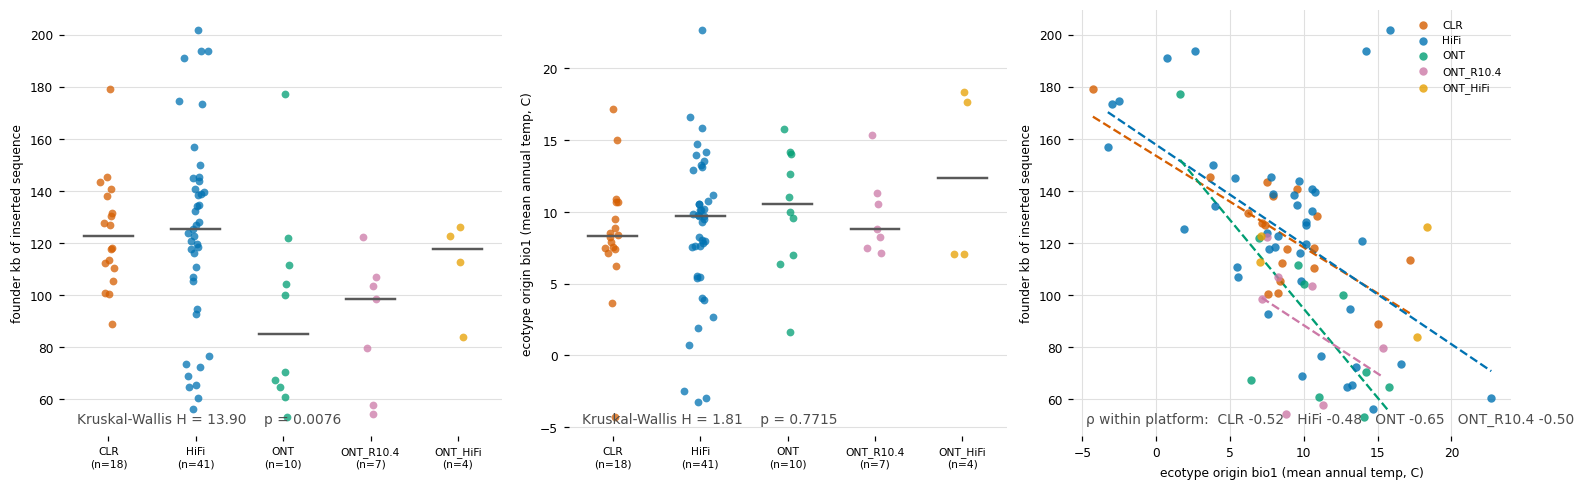

median kb inserted by platform:
  CLR         n= 18  kb=  122.5  origin bio1=  8.34  N50= 14.29 Mb
  HiFi        n= 41  kb=  125.4  origin bio1=  9.69  N50= 13.54 Mb
  ONT         n= 10  kb=   85.3  origin bio1= 10.53  N50= 12.20 Mb
  ONT_R10.4   n=  7  kb=   98.7  origin bio1=  8.78  N50= 22.68 Mb
  ONT_HiFi    n=  4  kb=  117.7  origin bio1= 12.39  N50= 24.14 Mb
  Kruskal-Wallis kb inserted   : H=13.90 p=0.0076
  Kruskal-Wallis origin bio1   : H=1.81 p=0.7715
  Kruskal-Wallis gamma_bio1    : H=7.04 p=0.1337

  N50 vs kb inserted: rho=-0.235 (p=0.036) | N50 vs origin bio1: rho=+0.177

  kb~origin within each platform:
    CLR         n= 18  kb~origin -0.523 (p=0.0259)   kb~gamma -0.393 (p=0.1065)
    HiFi        n= 41  kb~origin -0.479 (p=0.0015)   kb~gamma -0.534 (p=0.0003)
    ONT         n= 10  kb~origin -0.648 (p=0.0425)   kb~gamma -0.733 (p=0.0158)
    ONT_R10.4   n=  7  kb~origin -0.500 (p=0.2532)   kb~gamma -0.893 (p=0.0068)


In [8]:

TC=np.load(f"{G}/founder_assembly_technology.npz",allow_pickle=True)
tech=TC["tech"].astype(str); n50=TC["n50"]; okt=TC["ok"].astype(bool)
tl=[t for t in ["CLR","HiFi","ONT","ONT_R10.4","ONT_HiFi"] if (okt&(tech==t)).sum()>=2]
TCOL=dict(zip(tl,["#D55E00","#0072B2","#009E73","#CC79A7","#E69F00"]))

fig,ax=plt.subplots(1,3,figsize=(15,4.5))
for a,(v,yl) in zip(ax[:2],[(KB,"founder kb of inserted sequence"),
                            (home1,"ecotype origin bio1 (mean annual temp, C)")]):
    style(a,axis="y")
    for i,t in enumerate(tl):
        m=okt&(tech==t); c=TCOL[t]
        a.scatter(np.full(m.sum(),i)+np.random.default_rng(1).normal(0,0.07,m.sum()),v[m],
                  s=26,color=c,alpha=0.75,linewidths=0,zorder=3)
        a.plot([i-0.28,i+0.28],[np.median(v[m])]*2,color="0.35",lw=1.6,zorder=4)
    a.set_xticks(range(len(tl))); a.set_xticklabels([f"{t}\n(n={int((okt&(tech==t)).sum())})" for t in tl],fontsize=7)
    a.set_ylabel(yl)
    kw=stats.kruskal(*[v[okt&(tech==t)] for t in tl])
    stat(a,f"Kruskal-Wallis H = {kw.statistic:.2f}    p = {pfmt(kw.pvalue)}")

style(ax[2])
for t in tl:
    m=okt&(tech==t)
    ax[2].scatter(home1[m],KB[m],s=30,color=TCOL[t],alpha=0.8,linewidths=0,label=t,zorder=3)
    if m.sum()>=6: fitline(ax[2],home1[m],KB[m],color=TCOL[t])
ax[2].set_xlabel("ecotype origin bio1 (mean annual temp, C)")
ax[2].set_ylabel("founder kb of inserted sequence")
ax[2].legend(frameon=False,fontsize=7,loc="upper right")
rr=[f"{t} {stats.spearmanr(KB[okt&(tech==t)],home1[okt&(tech==t)]).correlation:+.2f}"
    for t in tl if (okt&(tech==t)).sum()>=6]
stat(ax[2],"ρ within platform:  "+"   ".join(rr))
fig.tight_layout(); fig.savefig(f"{G}/plots/confound_technology.png",dpi=130,bbox_inches="tight"); plt.show()

print("median kb inserted by platform:")
for t in tl:
    m=okt&(tech==t)
    print(f"  {t:<11} n={int(m.sum()):>3}  kb={np.median(KB[m]):>7.1f}  origin bio1={np.median(home1[m]):>6.2f}  N50={np.nanmedian(n50[m])/1e6:>6.2f} Mb")
for nm,v in (("kb inserted",KB),("origin bio1",home1),("gamma_bio1",g1)):
    kw=stats.kruskal(*[v[okt&(tech==t)] for t in tl])
    print(f"  Kruskal-Wallis {nm:<14}: H={kw.statistic:.2f} p={kw.pvalue:.4f}")
m=okt&np.isfinite(n50)
print(f"\n  N50 vs kb inserted: rho={stats.spearmanr(n50[m],KB[m]).correlation:+.3f} "
      f"(p={stats.spearmanr(n50[m],KB[m]).pvalue:.3f}) | N50 vs origin bio1: "
      f"rho={stats.spearmanr(n50[m],home1[m]).correlation:+.3f}")
print("\n  kb~origin within each platform:")
for t in tl:
    m=okt&(tech==t)
    if m.sum()<6: continue
    r,pv=stats.spearmanr(KB[m],home1[m]); r2,p2=stats.spearmanr(KB[m],g1[m])
    print(f"    {t:<11} n={int(m.sum()):>3}  kb~origin {r:+.3f} (p={pv:.4f})   kb~gamma {r2:+.3f} (p={p2:.4f})")


**Verdict: technology genuinely affects the measurement, but is not confounded with climate.**

**The platform effect is real and worth knowing.** Inserted kb differs significantly across platforms
(Kruskal-Wallis p = 0.0076): ONT assemblies yield a median of 85 kb and ONT_R10.4 99 kb, against HiFi
125 kb and CLR 123 kb — roughly a 30% deficit for the ONT-based platforms. This is a genuine technical
effect on how much inserted sequence gets called, and it had not been quantified before.

**But it cannot produce the result**, for three independent reasons:
- **Platform is not confounded with ecotype origin.** Origin bio1 does not differ across platforms at
  all (Kruskal-Wallis H = 1.81, **p = 0.77**; medians 8.3-12.4 C with no ordering). Nor does gamma
  (p = 0.13). A technical effect orthogonal to the predictor cannot generate a spurious association.
- **The relationship holds within every platform separately** — CLR -0.523 (p = 0.026), HiFi -0.479
  (p = 0.0015), ONT -0.648 (p = 0.043). Same sign, similar magnitude, three independent platforms.
- **Controlling for everything at once changes nothing**: technology dummies + N50 + assembly size
  together move kb~origin from -0.523 to **-0.518**, and kb~gamma from -0.644 to **-0.607**.

**Contiguity is a minor and wrong-signed effect.** N50 vs inserted kb is -0.235 (p = 0.036) and gaps
+0.233 (p = 0.037) — *more* contiguous assemblies yield slightly *less* inserted sequence, the opposite
of a "better assembly finds more insertions" artifact. Neither tracks origin climate (N50 p = 0.12).

This closes the last technical gap flagged in earlier passes. Note it applies to the 80 assembled
founders; the 151 PanGenie founders have no assembly and were covered separately in §2.4/§2.4b, where
the relationship is if anything stronger.

### 2.5 Where the insertion-rich founders are

Founder inserted sequence on the map, and in origin-climate PC space. PC1 and PC2 of the 19 origin
bioclim axes carry 38.3% and 29.9% of the variance; their meaning is read off their correlation with
bio1 and bio18, annotated in-panel.

*(Raw lon/lat — no coastline basemap, since no cartopy/geopandas is installed in any environment on
this cluster. `mamba install -c conda-forge cartopy` into `basic` if a basemap is wanted.)*

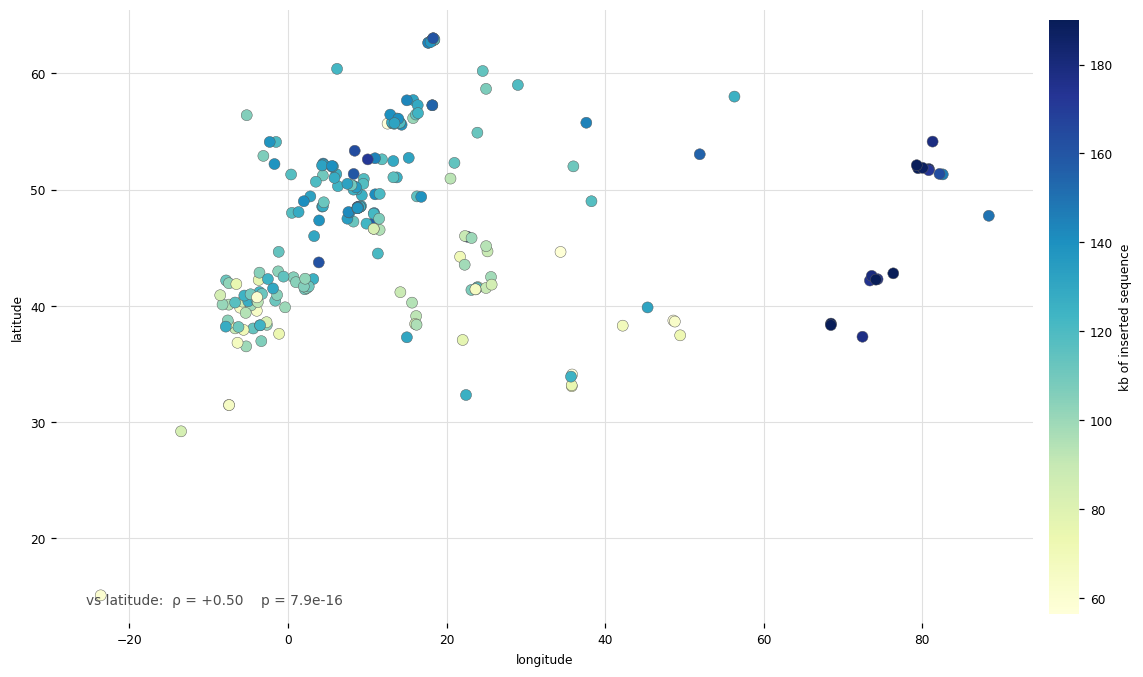

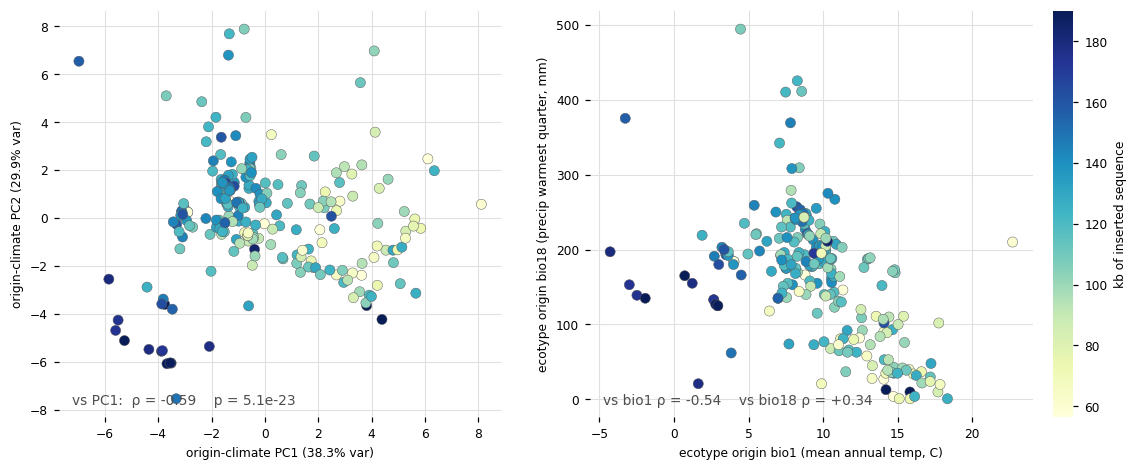

kb inserted vs latitude    rho=+0.497 p=7.95e-16
kb inserted vs origin bio1 rho=-0.542
kb inserted vs origin bio18 rho=+0.337
PC1 ~ bio1 +0.97, bio18 -0.64 | PC2 ~ bio1 -0.02, bio18 +0.51


In [9]:


geo=pd.read_csv(f"{KEY}/1001g_regmap_grenet_ecotype_info_corrected_2024May16.csv")
geo["ecotype_id"]=geo["ecotype_id"].astype(str); gm=geo.set_index("ecotype_id")
lat=np.array([float(gm.loc[f,"Latitude_corrected"]) if f in gm.index else np.nan for f in fid])
lon=np.array([float(gm.loc[f,"Longitude_corrected"]) if f in gm.index else np.nan for f in fid])
ok=np.isfinite(lat)&np.isfinite(lon)

vmin,vmax=np.quantile(KB,[0.02,0.98])
norm=mpl.colors.Normalize(vmin,vmax); cmap=mpl.cm.YlGnBu
rlat=stats.spearmanr(lat[ok],KB[ok])

figM,aM=plt.subplots(figsize=(13,6.2))
style(aM)
sc=aM.scatter(lon[ok],lat[ok],c=KB[ok],cmap=cmap,norm=norm,s=52,linewidths=0.3,
              edgecolor="0.35",zorder=3)
aM.set_xlabel("longitude"); aM.set_ylabel("latitude")
aM.set_aspect(1/np.cos(np.deg2rad(np.nanmean(lat[ok]))))
stat(aM,rho_txt(rlat.correlation,rlat.pvalue,pre="vs latitude:  "))
cb=figM.colorbar(sc,ax=aM,label="kb of inserted sequence",fraction=0.022,pad=0.012)
cb.outline.set_visible(False)
figM.tight_layout(); figM.savefig(f"{G}/plots/confound_map.png",dpi=130,bbox_inches="tight"); plt.show()

fig,ax=plt.subplots(1,2,figsize=(12,4.8))
style(ax[0])
ax[0].scatter(PCs[:,0],PCs[:,1],c=KB,cmap=cmap,norm=norm,s=44,linewidths=0.3,edgecolor="0.35",zorder=3)
ax[0].set_xlabel(f"origin-climate PC1 ({varexp[0]*100:.1f}% var)")
ax[0].set_ylabel(f"origin-climate PC2 ({varexp[1]*100:.1f}% var)")
ri1=stats.spearmanr(PCs[:,0],KB)
stat(ax[0],rho_txt(ri1.correlation,ri1.pvalue,pre="vs PC1:  "))

style(ax[1])
sc2=ax[1].scatter(home1,home18,c=KB,cmap=cmap,norm=norm,s=44,linewidths=0.3,edgecolor="0.35",zorder=3)
ax[1].set_xlabel("ecotype origin bio1 (mean annual temp, C)")
ax[1].set_ylabel("ecotype origin bio18 (precip warmest quarter, mm)")
r_b1=stats.spearmanr(home1,KB); r_b18=stats.spearmanr(home18,KB)
stat(ax[1],f"vs bio1 ρ = {r_b1.correlation:+.2f}    vs bio18 ρ = {r_b18.correlation:+.2f}")
cb2=fig.colorbar(sc2,ax=ax,label="kb of inserted sequence",fraction=0.028,pad=0.02)
cb2.outline.set_visible(False)
fig.savefig(f"{G}/plots/confound_climate_space.png",dpi=130,bbox_inches="tight"); plt.show()

print(f"kb inserted vs latitude    rho={rlat.correlation:+.3f} p={rlat.pvalue:.2e}")
print(f"kb inserted vs origin bio1 rho={r_b1.correlation:+.3f}")
print(f"kb inserted vs origin bio18 rho={r_b18.correlation:+.3f}")
print(f"PC1 ~ bio1 {stats.spearmanr(PCs[:,0],home1).correlation:+.2f}, bio18 {stats.spearmanr(PCs[:,0],home18).correlation:+.2f} | "
      f"PC2 ~ bio1 {stats.spearmanr(PCs[:,1],home1).correlation:+.2f}, bio18 {stats.spearmanr(PCs[:,1],home18).correlation:+.2f}")


## 3. Summary

**The measure: kb of sequence present in a founder and absent from Col-0.** Median 121 kb. Chosen over
the insertion-count fraction used in earlier drafts because it is both the plainest to state and the
best behaved — strongest predictor on every test, the only insertion measure with no cactus/PanGenie
panel artifact, and the only SV measure independent of Col-0 divergence.

| # | hypothesis | test | result | verdict |
|---|---|---|---|---|
| 1 | panel asymmetry (cactus vs PanGenie) | Spearman + MWU; within-half slopes | **kb** rho=-0.056 p=0.40; but insertion **count** rho=+0.378 p<0.001 | **ruled out for kb; real for counts** |
| 2 | founder provenance / local adaptation | escalating partial correlation, 2 → 19 origin axes | attenuates then plateaus; chain link 3 does not collapse when origin is fixed | **real, partial, not sufficient** |
| 3 | divergence from Col-0 (reference bias) | divergence vs climate; entanglement per measure | divergence vs origin bio1 rho=-0.063 **p=0.34**; kb vs divergence rho=+0.088 **p=0.18** | **ruled out for kb** |
| 4 | panel construction (call quality, assembly) | call-rate control; within-panel-half slopes | call rate fixed: -0.542 → -0.506; holds in the **no-assembly** half at -0.576 | **ruled out** |

### What this establishes
Ecotypes from colder origins carry more inserted sequence (rho = -0.542), and those same ecotypes
decline as gardens warm. That is not produced by the panel split, by call quality, by distance from the
Col-0 reference, or by assembly-based measurement — it reproduces at full strength in the 151 founders
who have no assembly at all. Provenance accounts for part of it and the rest survives control on all 19
origin bioclim axes.

Deletions show nothing on any measure and behave as a pure divergence readout (deletion count vs SNP
divergence rho = +0.958), which is why they serve as the internal null control throughout.

### What it does not establish
That individual SVs are under selection. Per-variant beta is a deterministic projection of founder
trajectories through fixed carrier sets, so the per-variant arm and this founder arm are **one result,
not two** — and neither can isolate SV-specific selection from selection on anything else those
founders carry.

### What remains open
1. The residual after full control is consistent with inserted sequence being deleterious under
   heat/drought stress, but equally with inserted kb tagging another founder property that bioclim does
   not measure — TE content, genome size, dormancy, demographic history.
2. **Sequencing technology, assembly N50 and assembly length are untested** — that metadata is not in
   this repo (§2.4).
3. The divergence proxy uses common segregating SNPs only, and Col-0 is not a founder (§2.3 caveat).

Standing caveats from `SV_TEMPORAL_PURGING_SUMMARY.md` are unchanged: no ancestral polarization
(insertions are relative to TAIR10/Col-0, not an outgroup), and no independent local-mode SV frequency.